In [1]:
print("Test working")

Test working


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pydicom

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import os

base_path = r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge"

print(os.path.exists(base_path))

True


In [4]:
import pandas as pd

labels = pd.read_csv(
    r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_labels.csv"
)

class_info = pd.read_csv(
    r"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_detailed_class_info.csv"
)

print(labels.head())
print("\n")
print(class_info.head())

                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1


                              patientId                         class
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6  No Lung Opacity / Not Normal
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd  No Lung Opacity / Not Normal
2  00322d4d-1c29-4943-afc9-b6754be640eb  No Lung Opacity / Not Normal
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5                        Normal
4  00436515-870c-4b36-a041-de91049b9ab4                  Lung Opacity


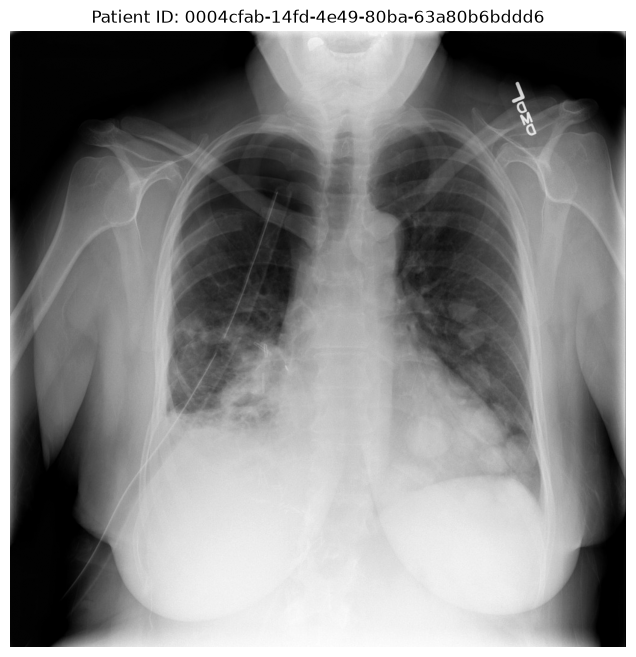

In [5]:
import pydicom
import matplotlib.pyplot as plt

patient_id = labels.iloc[0]["patientId"]

image_path = rf"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_images\{patient_id}.dcm"

ds = pydicom.dcmread(image_path)

plt.figure(figsize=(8,8))
plt.imshow(ds.pixel_array, cmap="gray")
plt.title(f"Patient ID: {patient_id}")
plt.axis("off")
plt.show()

In [6]:
pneumonia_cases = labels[labels["Target"] == 1]

print("Number of pneumonia records:", len(pneumonia_cases))
pneumonia_cases.head()

Number of pneumonia records: 9555


,patientId,x,y,width,height,Target
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1
14,00aecb01-a116-45a2-956c-08d2fa55433f,288.0,322.0,94.0,135.0,1


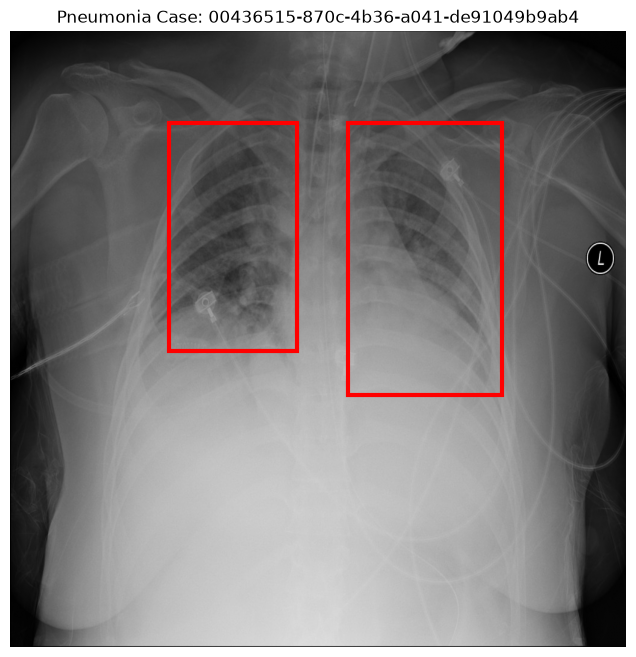

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom

# First pneumonia patient
patient_id = pneumonia_cases.iloc[0]["patientId"]

# Load image
image_path = rf"C:\Users\anudi\Downloads\MSc_Research\rsna-pneumonia-detection-challenge\stage_2_train_images\{patient_id}.dcm"

ds = pydicom.dcmread(image_path)
image = ds.pixel_array

# Get all boxes for this patient
rows = labels[labels["patientId"] == patient_id]

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(image, cmap="gray")

# Draw bounding boxes
for _, row in rows.iterrows():
    rect = patches.Rectangle(
        (row["x"], row["y"]),
        row["width"],
        row["height"],
        linewidth=3,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

ax.set_title(f"Pneumonia Case: {patient_id}")
ax.axis("off")

plt.show()